 Libraries import

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")

In [3]:
import sys
!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Data Load

In [11]:
fake = pd.read_csv(r'E:\AI projects\fake-news-detector\data\Fake.csv')
true = pd.read_csv(r'E:\AI projects\fake-news-detector\data\True.csv')

# Label add karo
fake['label'] = 0   # 0 = Fake
true['label'] = 1   # 1 = Real

# Combine karo
df = pd.concat([fake, true], ignore_index=True)

print("Total records:", df.shape[0])
print("Fake news:", len(fake))
print("Real news:", len(true))
df.head()

Total records: 44898
Fake news: 23481
Real news: 21417


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


 Class Distribution

C:\Users\admin\AppData\Local\Temp\ipykernel_9428\4144972520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df,


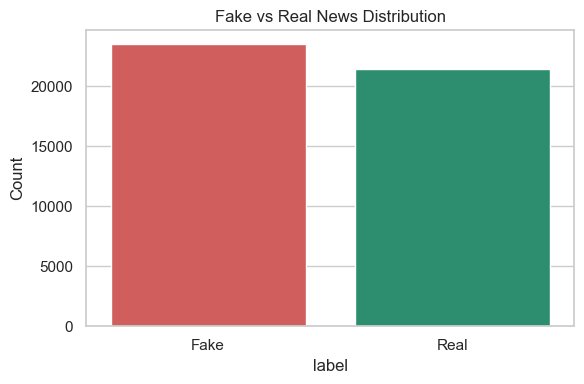

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df,
              palette=['#E24B4A', '#1D9E75'])
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Fake vs Real News Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

WordCloud Fake News

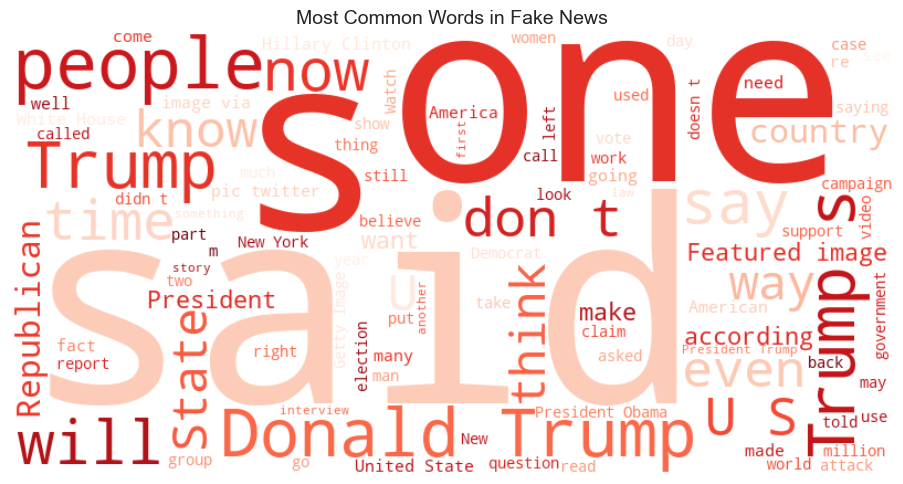

In [15]:
fake_text = " ".join(fake['text'].dropna().astype(str).tolist())

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(fake_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Fake News', fontsize=14)
plt.tight_layout()
plt.show()

Text Length Analysis

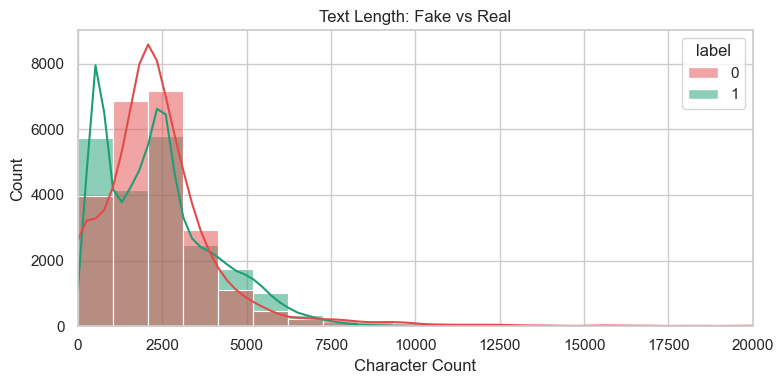

In [16]:
df['text_length'] = df['text'].astype(str).apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='text_length', hue='label',
             bins=50, kde=True,
             palette={0: '#E24B4A', 1: '#1D9E75'})
plt.title('Text Length: Fake vs Real')
plt.xlabel('Character Count')
plt.xlim(0, 20000)
plt.tight_layout()
plt.show()